# Multitask RobotEmotions classifiers

This notebook builds the new multimodal evaluation dataset on top of the original RobotEmotions export pipeline, applies the correlation + DTW pose/IMU alignment, and runs the 7 experiment settings.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(root for root in candidate_roots if (root / 'pose_module').exists() and (root / 'evaluation').exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.classifiers import (
    ALL_CAPTURE_BLACKLIST,
    WindowedDatasetConfig,
    build_classifier_capture_table,
    build_windowed_multimodal_dataset,
)

try:
    from evaluation.classifiers import (
        EXPERIMENT_SPECS,
        ModelConfig,
        SplitConfig,
        TrainingConfig,
        run_experiment_suite,
    )
    TORCH_READY = True
    TORCH_IMPORT_ERROR = None
except ImportError as exc:
    TORCH_READY = False
    TORCH_IMPORT_ERROR = exc

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 260)
PROJECT_ROOT


PosixPath('/home/henriquesouza/IMUGPT')

## Dataset setup

The config below keeps the default 81-frame windows at 20 Hz. `max_windows_per_capture` is intentionally small here so the notebook stays responsive while we iterate; set it to `None` for the full evaluation sweep.

In [2]:
OUTPUT_ROOT = PROJECT_ROOT / 'output' / 'robot_emotions_virtual_imu_v2_all_dataset'
IMU_FEATURE_MODE = 'acc_euler'  # options: 'acc_gyro', 'acc_euler'
DATASET_CONFIG = WindowedDatasetConfig(
    window_size=81,
    overlap=0.5,
    synthetic_variant='raw',
    imu_feature_mode=IMU_FEATURE_MODE,
    selected_sensors=None,
    max_windows_per_capture=None,
    random_state=42,
)

CAPTURES_DF_ALL = build_classifier_capture_table(OUTPUT_ROOT, drop_blacklisted=False)
CAPTURES_DF = build_classifier_capture_table(OUTPUT_ROOT)
display(CAPTURES_DF[['clip_id', 'domain', 'user_id', 'tag_number', 'emotion', 'modality', 'stimulus', 'status']].head())
print({
    'num_captures_total_before_blacklist': len(CAPTURES_DF_ALL),
    'num_blacklisted_capture_specs': len(ALL_CAPTURE_BLACKLIST),
    'num_captures_after_blacklist': len(CAPTURES_DF),
    'domains': sorted(CAPTURES_DF['domain'].unique().tolist()),
})

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01,10ms,2,1,Neutrality,Standing,None,warning
1,robot_emotions_10ms_u02_tag05,10ms,2,5,Sadness,Sitting,Visual methods,warning
2,robot_emotions_10ms_u02_tag06,10ms,2,6,Sadness,Sitting,Autobiographical recall,warning
3,robot_emotions_10ms_u02_tag07,10ms,2,7,Sadness,Standing,Autobiographical recall,warning
4,robot_emotions_10ms_u02_tag09,10ms,2,9,Happiness,Sitting,Visual methods,warning


{'num_captures_total_before_blacklist': 89, 'num_blacklisted_capture_specs': 9, 'num_captures_after_blacklist': 80, 'domains': ['10ms', '30ms']}


## Dataset build and alignment diagnostics

This cell loads `pose3d.npz`, real `imu.npz`, and synthetic `virtual_imu.npz`, aligns real IMU to the pose timeline with correlation + DTW, and emits synchronized windows for pose, real IMU, and synthetic IMU.

In [3]:
DATASET_BUNDLE = build_windowed_multimodal_dataset(
    OUTPUT_ROOT,
    config=DATASET_CONFIG,
    captures_df=CAPTURES_DF,
)

display(DATASET_BUNDLE['metadata'].head())
display(DATASET_BUNDLE['alignment_summary'].head())
print({
    'num_samples': len(DATASET_BUNDLE['metadata']),
    'pose_shape': DATASET_BUNDLE['pose_windows'].shape,
    'imu_real_shape': DATASET_BUNDLE['imu_real_windows'].shape,
    'imu_synthetic_shape': DATASET_BUNDLE['imu_synthetic_windows'].shape,
    'imu_feature_mode': DATASET_BUNDLE['imu_feature_mode'],
    'selected_sensors': DATASET_BUNDLE['selected_sensors'],
})

,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,imu_feature_mode,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01::window_0000,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
1,robot_emotions_10ms_u02_tag01::window_0001,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
2,robot_emotions_10ms_u02_tag01::window_0002,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,2,80,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
3,robot_emotions_10ms_u02_tag01::window_0003,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,3,120,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
4,robot_emotions_10ms_u02_tag01::window_0004,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,4,160,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9


,clip_id,selected_sensors,imu_feature_mode,lag_samples,lag_seconds,correlation_before_dtw,correlation_after_dtw,dtw_normalized_distance,aligned_frequency_hz,num_aligned_frames
0,robot_emotions_10ms_u02_tag01,"[waist, head, left_forearm, right_forearm]",acc_euler,-4,-0.133484,0.026847,0.671229,0.178128,29.966164,2082
1,robot_emotions_10ms_u02_tag05,"[waist, head, left_forearm, right_forearm]",acc_euler,13,0.433823,0.038990,0.567443,0.188057,29.966164,2075
2,robot_emotions_10ms_u02_tag06,"[waist, head, left_forearm, right_forearm]",acc_euler,-15,-0.500565,0.235031,0.712376,0.184795,29.966164,2150
3,robot_emotions_10ms_u02_tag07,"[waist, head, left_forearm, right_forearm]",acc_euler,0,0.000000,0.266520,0.766502,0.161656,29.966164,1938
4,robot_emotions_10ms_u02_tag09,"[waist, head, left_forearm, right_forearm]",acc_euler,9,0.300339,0.116164,0.561349,0.218361,29.966164,2041


{'num_samples': 4075, 'pose_shape': (4075, 81, 22, 16), 'imu_real_shape': (4075, 81, 4, 12), 'imu_synthetic_shape': (4075, 81, 4, 12), 'imu_feature_mode': 'acc_euler', 'selected_sensors': ['waist', 'head', 'left_forearm', 'right_forearm']}


,emotion,modality,stimulus,num_windows
0,Sadness,Sitting,Visual methods,504
1,Neutrality,Standing,None,462
2,Neutrality,Sitting,None,423
3,Happiness,Sitting,Visual methods,400
4,Boredom,Sitting,Visual methods,361
5,Happiness,Sitting,Autobiographical recall,332
6,Curiosity,Standing,Simulation,314
7,Sadness,Sitting,Autobiographical recall,311
8,Boredom,Standing,Visual methods,308
9,Happiness,Standing,Autobiographical recall,246


,lag_samples,correlation_after_dtw,dtw_normalized_distance
count,80.000000,80.000000,80.000000
mean,1.325000,0.615592,0.191772
std,14.024188,0.160407,0.034099
min,-20.000000,0.071088,0.152942
25%,-11.250000,0.555404,0.170511
50%,1.000000,0.646358,0.183319
75%,14.250000,0.729500,0.202906
max,20.000000,0.855669,0.384351


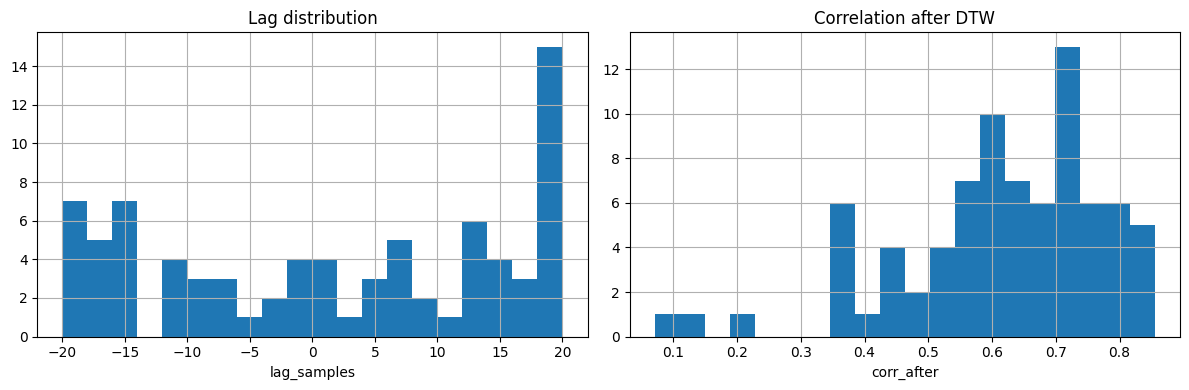

In [4]:
label_distribution = (
    DATASET_BUNDLE['metadata'][['emotion', 'modality', 'stimulus']]
    .value_counts()
    .rename('num_windows')
    .reset_index()
)
display(label_distribution.head(20))

alignment_summary = DATASET_BUNDLE['alignment_summary'][['lag_samples', 'correlation_after_dtw', 'dtw_normalized_distance']]
display(alignment_summary.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
DATASET_BUNDLE['alignment_summary']['lag_samples'].hist(ax=axes[0], bins=20)
axes[0].set_title('Lag distribution')
axes[0].set_xlabel('lag_samples')
DATASET_BUNDLE['alignment_summary']['correlation_after_dtw'].hist(ax=axes[1], bins=20)
axes[1].set_title('Correlation after DTW')
axes[1].set_xlabel('corr_after')
plt.tight_layout()


## Multitask experiment suite

The suite below runs the 7 experiment settings and reports the mean score across subject-group folds.


In [ ]:
if not TORCH_READY:
    display(Markdown(f"**PyTorch is not available in the current `.venv`**: `{TORCH_IMPORT_ERROR}`"))
    SUITE_RESULT = None
else:
    SPLIT_CONFIG = SplitConfig(
        n_splits=5,
        random_state=42,
    )
    MODEL_CONFIG = ModelConfig(
        hidden_dim=128,
        dropout=0.1,
        trunk_blocks=2,
        modality_dropout_p=0.1,
    )
    TRAINING_CONFIG = TrainingConfig(
        batch_size=64,
        max_epochs=10,
        learning_rate=2e-3,
        weight_decay=1e-4,
        device='cuda',
        domain_loss_weight=0.1,
        flat_tag_loss_weight=0.3,
        emotion_loss_weight=1.0,
        modality_loss_weight=0.3,
        stimulus_loss_weight=0.3,
        use_cb_focal=False,
    )
    SUITE_RESULT = run_experiment_suite(
        DATASET_BUNDLE,
        experiment_names=list(EXPERIMENT_SPECS.keys()),
        split_config=SPLIT_CONFIG,
        model_config=MODEL_CONFIG,
        training_config=TRAINING_CONFIG,
    )


In [6]:
requested_order = [
    'vision_only',
    'imu_only_r2r',
    'imu_only_s2r',
    'imu_only_mixed2r',
    'vision_imu_r2r',
    'vision_imu_s2r',
    'vision_imu_mixed2r',
]
order_map = {name: idx for idx, name in enumerate(requested_order)}

summary_sorted = SUITE_RESULT['summary'].copy()
summary_sorted['experiment_name'] = summary_sorted['experiment_name'].astype(str)
summary_sorted['_sort_key'] = summary_sorted['experiment_name'].map(order_map).fillna(len(requested_order))
summary_sorted = summary_sorted.sort_values('_sort_key', kind='stable').drop(columns=['_sort_key']).reset_index(drop=True)

display(summary_sorted)
display(SUITE_RESULT['domain_gap_summary'])
display(SUITE_RESULT['results_frame'])

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1_supported_oof,emotion_macro_f1_all_oof,modality_macro_f1_oof,stimulus_macro_f1_oof,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,unsupported_classes,num_oof_samples
0,vision_only,0.585831,0.531785,0.568229,0.505381,0.369646,0.316839,0.899936,0.487911,0.369646,0.899936,0.487911,emotion: Anger,4075
1,imu_only_r2r,0.560181,0.523049,0.540579,0.493645,0.411652,0.352845,0.738979,0.529913,0.411652,0.738979,0.529913,emotion: Anger,4075
2,imu_only_s2r,0.452095,0.404406,0.439651,0.385739,0.261336,0.224002,0.709161,0.385789,0.261336,0.709161,0.385789,emotion: Anger,4075
3,imu_only_mixed2r,0.535881,0.496518,0.517861,0.469488,0.378430,0.324368,0.747332,0.481882,0.378430,0.747332,0.481882,emotion: Anger,4075
4,vision_imu_r2r,0.601877,0.556523,0.581855,0.526490,0.420462,0.360396,0.862037,0.523130,0.420462,0.862037,0.523130,emotion: Anger,4075
5,vision_imu_s2r,0.551168,0.503257,0.534047,0.477577,0.359526,0.308165,0.814528,0.479449,0.359526,0.814528,0.479449,emotion: Anger,4075
6,vision_imu_mixed2r,0.625705,0.578898,0.604825,0.547578,0.438476,0.375837,0.889056,0.549583,0.438476,0.889056,0.549583,emotion: Anger,4075


,metric,value
0,imu_only_gap_s2r,0.108086
1,imu_only_gap_mixed2r,0.024300
2,imu_only_gain_mixed_over_r2r,-0.024300
3,imu_only_gain_mixed_over_s2r,0.083786
4,vision_imu_gap_s2r,0.050709
5,vision_imu_gap_mixed2r,-0.023829
6,vision_imu_gain_mixed_over_r2r,0.023829
7,vision_imu_gain_mixed_over_s2r,0.074537


,experiment_name,split_id,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1,emotion_macro_f1_all,modality_macro_f1,modality_macro_f1_all,stimulus_macro_f1,stimulus_macro_f1_all
0,vision_only,0,0.526184,0.481460,0.509646,0.456654,0.347290,0.297677,0.745235,0.745235,0.486027,0.486027
1,vision_only,1,0.627771,0.588527,0.605352,0.554899,0.470798,0.403541,0.931358,0.931358,0.481156,0.481156
2,vision_only,2,0.627908,0.576391,0.607821,0.546259,0.421838,0.361576,0.858614,0.858614,0.603272,0.603272
3,vision_only,3,0.561557,0.500070,0.546528,0.477527,0.315609,0.270522,0.969331,0.969331,0.399731,0.399731
4,vision_only,4,0.582898,0.513820,0.568299,0.491921,0.306587,0.262789,0.994810,0.994810,0.447298,0.447298
5,imu_only_r2r,0,0.596879,0.573078,0.572990,0.537244,0.501674,0.430006,0.668893,0.668893,0.620069,0.620069
6,imu_only_r2r,1,0.610569,0.558349,0.591441,0.529657,0.401690,0.344305,0.876080,0.876080,0.553938,0.553938
7,imu_only_r2r,2,0.471593,0.428673,0.457311,0.407251,0.299914,0.257069,0.689738,0.689738,0.425127,0.425127
8,imu_only_r2r,3,0.610305,0.562722,0.590306,0.532724,0.419975,0.359979,0.833085,0.833085,0.577854,0.577854
9,imu_only_r2r,4,0.459845,0.433765,0.442915,0.408370,0.355526,0.304736,0.612247,0.612247,0.411762,0.411762


## Optional confusion matrices

When the suite runs, this last block visualizes confusion matrices for the best experiment on its best fold.


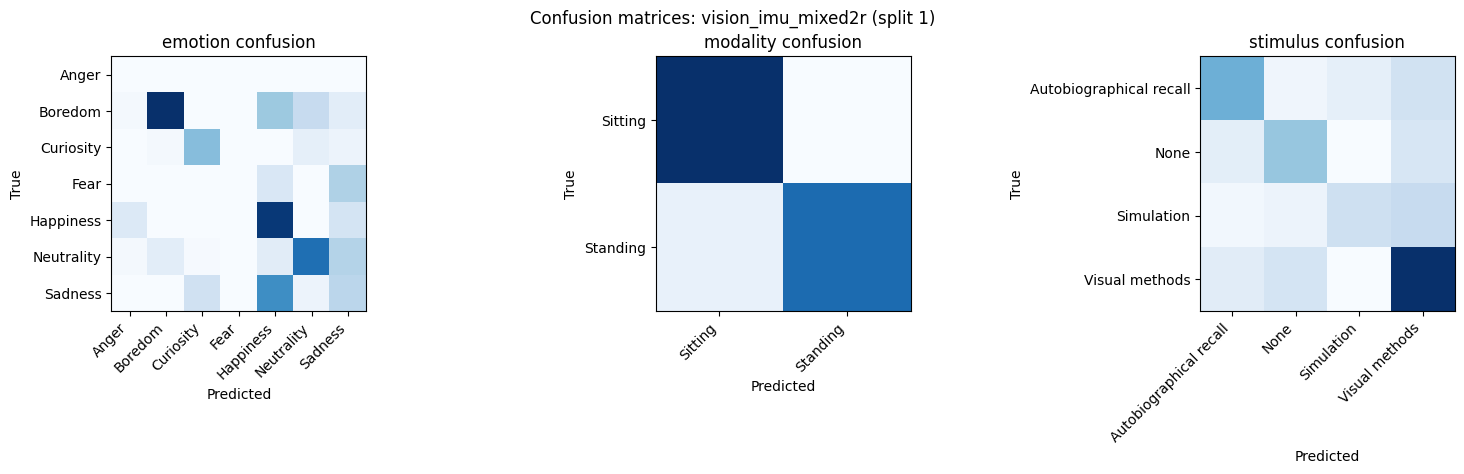

In [7]:
if SUITE_RESULT is not None:
    from evaluation.classifiers.metrics import plot_confusion_matrices

    best_experiment_name = SUITE_RESULT['summary'].iloc[0]['experiment_name']
    best_result = max(
        (
            result for result in SUITE_RESULT['results']
            if result['experiment_name'] == best_experiment_name
        ),
        key=lambda result: float(result['metrics'].get('global_score_macro_f1_mean') or float('-inf')),
    )
    best_split_id = best_result.get('split_id')
    fig, axes = plot_confusion_matrices(best_result['metrics'], DATASET_BUNDLE['label_encoders'])
    split_suffix = '' if best_split_id is None else f' (split {best_split_id})'
    fig.suptitle(f'Confusion matrices: {best_experiment_name}{split_suffix}', y=1.02)
    plt.show()
